# Exploring Mutation Proximity to Ligand-Binding Sites in KEAP1

### Welcome.

In this module, you will explore how **cancer-associated mutations** may affect the function of **KEAP1**, a key protein involved in cellular defense against oxidative stress.

We will do this by:
- Mapping mutations onto real 3D protein structures 
- Identifying where ligands bind 
- Measuring distances between mutations and ligand-binding sites 

This structural perspective can reveal **which mutations might disrupt KEAP1's function** — a critical insight in understanding cancer biology.

> All the structural data you will use comes from public databases like the Protein Data Bank (PDB) and mutation datasets from large-scale cancer studies.

### Attribution

Part of this notebook adapts code from the [MMTF-Genomics](https://github.com/pwrose/mmtf-genomics) project developed by Dr. Peter Rose (RCSB PDB). The original work demonstrates how to map human genomic variants to 3D protein structures using Spark and G2S annotations.


## What is Structural Mapping?

Structural mapping is how we bridge DNA mutations and protein function. 
Here is what the workflow looks like:

1. **Mutation Input** 
 Start with a list of mutations observed in cancer genomes.

2. **Structure Retrieval** 
 Find 3D models of the KEAP1 protein from experimental or predicted sources (e.g., PDB, AlphaFold).

3. **Ligand Identification** 
 Detect biologically relevant ligands bound to KEAP1 (such as inhibitors or cofactors).

4. **3D Visualization** 
 Display the protein, ligand, and mutations all in one interactive view.

5. **Distance Calculation** 
 Measure how far each mutation is from the ligand; this tells us if a mutation might affect binding or activity.

> This lets us explore structure-function relationships; how the shape of the protein influences what it does, and how mutations might interfere.

## Import Required Libraries

We begin by importing the libraries needed for data handling, visualization, and protein structure analysis.

- **`os`**: used to interact with the file system
- **`py3Dmol`** : renders interactive 3D protein structures directly in the notebook
- **`ipywidgets`** : provides UI elements (checkboxes, dropdowns, buttons)
- **`pandas`** : handles mutation datasets and tabular data operations
- **`requests`** : allows downloading data from external sources like the PDB or AlphaFold DB
- **`Bio.PDB`** : from Biopython; parses and manipulates `.pdb` protein structure files
- **`mmtfPyspark.datasets.g2sDataset`** : maps genomic mutations to 3D structures
- **`io.StringIO`** : treats string data as a file for parsing PDB content
- **`numpy`** : supports numerical calculations like centroids and distances
- **`matplotlib.cm`** : handles color mapping (e.g., distance-based coloring)
- **`IPython.display`** : used to render widgets and outputs in notebook cells



In [1]:
import os
import py3Dmol
import ipywidgets as widgets
import pandas as pd
import requests
from Bio.PDB import PDBParser, PDBIO
from mmtfPyspark.datasets import g2sDataset
from io import StringIO
import numpy as np
from ipywidgets import Checkbox, HBox, Output
from IPython.display import display
from matplotlib import cm

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Load Ligand Blacklist

Some ligands in PDB structures are not biologically meaningful; for example, water molecules, salts, or buffer components.

This code loads a custom blacklist of ligand codes (like `HOH`, `SO4`, etc.) so we can filter them out later and focus only on **relevant molecules**, such as inhibitors or cofactors.


In [2]:
# Load blacklist
blacklist_path = './blacklist_updated.txt'
blacklist = set()
if os.path.exists(blacklist_path):
    with open(blacklist_path, 'r') as f:
        for line in f:
            code = line.strip().split(',')[0]
            blacklist.add(code)

## Filter PDB Chain Containing the Ligand

A protein structure file (PDB) may contain multiple chains (e.g., A, B, C...) and not all of them interact with the ligand.

This function:
- Downloads the full PDB file
- Identifies which chain contains the specified ligand
- Filters the file to keep **only that chain**, so our visualizations are cleaner and easier to interpret



In [3]:
# Function to filter PDB chains and retain only the chain containing the ligand
def filter_chains(pdb_id, ligand_resname):
    url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
    response = requests.get(url)
    
    if response.status_code == 200:
        pdb_lines = response.text.splitlines()
        filtered_lines = []
        chain_to_keep = None

        # Identify the chain that contains the ligand
        for line in pdb_lines:
            if line.startswith("HETATM") and ligand_resname in line:
                chain_to_keep = line[21]
                break

        if chain_to_keep is None:
            return None, None

        # Filter lines to include only the identified chain
        for line in pdb_lines:
            if (line.startswith("ATOM") or line.startswith("HETATM")) and line[21] == chain_to_keep:
                filtered_lines.append(line)
            elif line.startswith("TER") or line.startswith("ENDMDL"):
                filtered_lines.append(line)
            elif not (line.startswith("ATOM") or line.startswith("HETATM")):
                filtered_lines.append(line)

        filtered_pdb_content = '\n'.join(filtered_lines) + '\n'
        return filtered_pdb_content, chain_to_keep
    return None, None

## Detect Ligands in a PDB Structure

This function:
- Downloads the `.pdb` file
- Parses `HETNAM` lines (which describe ligands)
- Filters out blacklisted ligands
- Returns a list of meaningful ligand names found in the structure

These ligands are the candidates for calculating the binding site.


In [4]:
# Function to fetch and parse the PDB file to extract ligands, filtered by blacklist
def get_ligands_from_pdb(pdb_id):
    url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
    response = requests.get(url)
    
    if response.status_code == 200:
        pdb_file = response.text.split('\n')
        ligands = set()
        
        for line in pdb_file:
            if line.startswith("HETNAM"):
                parts = line.split()
                if len(parts) > 1:
                    lig = parts[1]
                    if lig not in blacklist and len(lig) > 1:
                        ligands.add(lig)
        
        return sorted(ligands) if ligands else ["No Ligand Found"]
    
    return ["No Ligand Found"]

## Load Mutation Data and Format IDs

This function loads your mutation dataset and creates a unique ID for each mutation in the format: 
`chr:g.positionREF>ALT` 
Example: `2:g.123456A>G`

This format is required by the **G2S dataset** for mapping mutations to 3D protein structures.


In [5]:
# Function to load mutation data and format mutation IDs
def load_and_format_mutations(input_file):
    df = pd.read_csv(input_file)
    
    def var_id(chrom, pos, ref, alt):
        return str(chrom) + ":g." + str(pos) + ref + ">" + alt
    
    df['var_id'] = df.apply(lambda x: var_id(x['CHROM'], x['POS'], x['REF'], x['ALT']), axis=1)
    return df

## Visualize Protein, Ligand, and Mutations (with py3Dmol)

This function uses `py3Dmol` to display the structure of the protein, the ligand, and any mapped mutations.

What it does:
- Loads the chain that contains the selected ligand
- Colors the protein as a light gray cartoon
- Colors the ligand in **red sticks**
- Colors the mutation sites in **blue sticks**
- Optionally shows labels for each mutation (e.g., `2:g.123456A>G`)

> This interactive viewer helps us **see where mutations happen relative to the ligand**, and gives a spatial sense of possible functional impact.


In [6]:
# Function to visualize protein structure, ligand, and mapped mutations using py3Dmol
def visualize_protein(pdb_id, ligand_resname, mutations_df, show_ligand=True, show_mutations=True, show_labels=True, filtered_pdb=None):
    viewer = py3Dmol.view(width=800, height=600)
    viewer.setStyle({"cartoon": {"color": "lightgray"}})

    # Filter chains to retain only the one with the ligand
    filtered_pdb, chain_to_keep = filter_chains(pdb_id, ligand_resname)
    chain_info = f'Chain containing ligand: {chain_to_keep}' if chain_to_keep else 'No specific chain identified'
    print(chain_info)
    if filtered_pdb is not None and len(filtered_pdb.strip()) > 0:
        viewer.addModel(filtered_pdb, 'pdb')
        viewer.setStyle({"cartoon": {"color": "lightgray"}})
        viewer.zoomTo()
        print(f'Showing filtered chain: {chain_to_keep}')
        
        viewer.setStyle({"cartoon": {"color": "lightgray"}})
        print(f'Showing chain: {chain_to_keep}')

    # Style ligand
    if ligand_resname != "No Ligand Found" and show_ligand:
        viewer.setStyle({"resn": ligand_resname}, {"stick": {"colorscheme": "redCarbon"}})

    # Style mutations for this PDB
    subset = mutations_df[mutations_df['structureId'] == pdb_id]
    if show_mutations and len(subset) > 0:
        for _, row in subset.iterrows():
            chain = row['chainId']
            resn = str(row['pdbPosition'])
            viewer.addStyle({"chain": chain, "resi": resn}, {"stick": {"colorscheme": "blueCarbon"}})
            #if show_labels and 'var_id' in row and pd.notna(row['var_id']):
             #   viewer.addLabel(str(row['var_id']), {"fontColor": "black", "backgroundColor": "white", "fontSize": 10}, {"chain": chain, "resi": resn})

    viewer.zoomTo()
    viewer.show()

## Update Ligand Options (Dropdown)

This function updates the list of available ligands whenever the PDB ID input changes.

Steps:
1. Get the PDB ID from the input widget
2. Call `get_ligands_from_pdb()` to retrieve all ligands
3. Update the dropdown widget with those ligand options


In [7]:
# Function to update ligand options when PDB ID changes
def update_ligand_options(change):
    pdb_id = pdb_id_widget.value
    ligands = get_ligands_from_pdb(pdb_id)
    ligand_resname_widget.options = ligands

## Update Visualization Panel

This function connects the widget settings (like checkboxes and dropdowns) to the actual 3D visualization.

- If the user clicks "Show structure" or changes a setting, this gets triggered.
- It reads the PDB ID, ligand, and toggle states from the widgets
- Then it calls `visualize_protein()` with those inputs to update the viewer


In [8]:
# Function to update visualization based on widget input
def update_visualization(change):
    show_ligand = show_ligand_widget.value
    show_mutations = show_mutations_widget.value
    with output_widget:
        output_widget.clear_output(wait=True)
        if ligand_resname_widget.value:
            visualize_protein(
                pdb_id_widget.value,
                ligand_resname_widget.value,
                mapped_pdbs,
                show_ligand=show_ligand,
                show_mutations=show_mutations,
            )

## Map Mutations to 3D Protein Structures with Spark + G2S

This function connects mutation data (like `2:g.123456A>G`) to actual residue positions in 3D protein structures.

We use:
- **G2S Dataset**: Maps genomic mutations to known PDB chains
- **PDB→UniProt mappings**: Adds biological context to structure
- **Taxonomy filters**: Keeps only human proteins (ignores bacteria, etc.)

Here is what it does:

1. **Query G2S** to retrieve structural matches for each mutation
2. **Filter for high sequence identity** (≥ 98%) to ensure accurate matches
3. **Keep only human proteins** using taxonomy metadata
4. **Map structure residues to UniProt residues** (adds biological relevance)
5. **Merge it all** into one DataFrame and save it as a CSV

This gives us a fully annotated structural dataset of mutations, residues, and the structures they land in.


In [9]:
# Adapted from Peter Rose's MMTF-Genomics project:
# https://github.com/pwrose/mmtf-genomics

import sys

# Ensure Spark uses the correct Python executable from the conda environment
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DUP2_Mutations") \
    .config("spark.driver.memory", "16G") \
    .config("spark.driver.maxResultSize", "8G") \
    .config("spark.executor.memory", "8G") \
    .getOrCreate()

from mmtfPyspark.datasets import g2sDataset, pdbjMineDataset, pdbToUniProt

def map_mutations_to_3D(mutation_df, output_file, spark):
    # variant IDs from mutation dataframe
    variant_ids = mutation_df['var_id'].tolist()

    # G2S annotations
    g2s_df = g2sDataset.get_full_dataset(variant_ids, ref_genome='hgvs-grch38').toPandas()

    # Filter by sequence identity to PDB sequence
    g2s_df['seqIdentity'] = g2s_df.identity/(g2s_df.seqTo - g2s_df.seqFrom + 1) * 100
    g2s_df = g2s_df[g2s_df.seqIdentity >= 98]
    
    # taxonomy data
    taxonomy_query = "SELECT * FROM sifts.pdb_chain_taxonomy WHERE scientific_name = 'Homo sapiens'"
    taxonomy_df = pdbjMineDataset.get_dataset(taxonomy_query).toPandas()
    
    # Join G2S and taxonomy
    enriched_df = g2s_df.merge(taxonomy_df, left_on=['structureId','chainId'], right_on=['pdbid','chain'], how='inner')
    enriched_df = enriched_df.drop(['pdbid','chain'], axis=1)  # remove redundant columns
    enriched_df['pdbPosition'] = enriched_df['pdbPosition'].astype('str') # must be string

    # PDB to UniProt mappings
    chains = set(enriched_df.structureChainId)
    up = pdbToUniProt.get_cached_residue_mappings().filter("pdbResNum IS NOT NULL").filter("uniprotNum IS NOT NULL")
    up_map = up.filter(up.structureChainId.isin(chains)).toPandas()
    up_map['uniprotNum'] = up_map.uniprotNum.astype('int') 

    # Join with UniProt data
    enriched_df = enriched_df.merge(up_map, left_on=['structureChainId','pdbPosition'], right_on=['structureChainId','pdbResNum'], how='left')

    # Convert to pandas DataFrame and save
    enriched_df = enriched_df.merge(mutation_df, left_on='variationId', right_on='var_id', how='inner')
    enriched_df.fillna('', inplace=True)
    enriched_df.to_csv(output_file, index=False)
    
    return enriched_df

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/09 15:04:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Load and Map Mutations to Protein Structures

In this step, we bring together everything we have built so far:

1. **Load the mutation dataset** 
 This includes chromosome, position, reference and alternate base (e.g., `chr2:123456 A>G`)

2. **Map each mutation to a 3D structure** 
 We use the `map_mutations_to_3D()` function to find:
 - Which PDB structure it maps to
 - What chain it appears in
 - What the corresponding residue is
 - How it connects to known UniProt annotations

3. **Fill in missing data** (with `''`) 
 This avoids errors when plotting or merging with other tables later.

> By the end of this step, we will have a mutation-annotated structural dataset ready for visualization and analysis.


In [10]:
# Load mutation data and map to structures
mutation_data = load_and_format_mutations("./KEAP1_mutations.csv")
mapped_pdbs = map_mutations_to_3D(mutation_data, "./KEAP1_mutations3d.csv", spark)
mapped_pdbs.fillna('', inplace=True)

## Build Interactive Controls to Explore Structures

Now that we have mutation-to-structure mappings, you can explore them visually.

This block sets up:
- **Checkboxes** to toggle ligand and mutation display
- **Dropdowns** to select a PDB structure and a specific ligand
- An output panel where the structure will be rendered
- Listeners that update the visualization automatically when you change any setting

> This makes the notebook feel like an interactive protein viewer — letting you explore mutation-ligand relationships in 3D.



In [11]:
# Toggle widgets
show_ligand_widget = widgets.Checkbox(value=False, description='Show Ligand')
show_mutations_widget = widgets.Checkbox(value=False, description='Show Mutations')

# Widget elements
pdb_ids = mapped_pdbs['structureId'].unique().tolist()
pdb_id_widget = widgets.Dropdown(options=pdb_ids, description='PDB ID:')
ligand_resname_widget = widgets.Dropdown(options=[], description='Ligand:')
output_widget = widgets.Output()

# Observe changes
show_ligand_widget.observe(update_visualization, names='value')
show_mutations_widget.observe(update_visualization, names='value')
pdb_id_widget.observe(update_ligand_options, names='value')
ligand_resname_widget.observe(update_visualization, names='value')

# Display widgets
display(pdb_id_widget, ligand_resname_widget, show_ligand_widget, show_mutations_widget, output_widget)

# Initial update calls (crucial step)
update_ligand_options(None)
update_visualization(None)

Dropdown(description='PDB ID:', options=('4L7B', '4IN4', '1U6D', '3VNH', '3VNG', '4IFJ', '1ZGK', '4XMB', '5X54…

Dropdown(description='Ligand:', options=(), value=None)

Checkbox(value=False, description='Show Ligand')

Checkbox(value=False, description='Show Mutations')

Output()

## Visualize High-Confidence AlphaFold Model

In this section, we use **AlphaFold** — a deep learning model that predicts protein structures — to visualize KEAP1 when no crystal structure is available.

However, not all residues are equally reliable. 
AlphaFold provides a **confidence score** (called the B-factor) for each atom. 
We only want to visualize **residues with high confidence** (typically ≥ 90).

Here is what we will do:

1. Download the predicted KEAP1 model from the [AlphaFold Protein Structure Database](https://alphafold.ebi.ac.uk)
2. Filter the structure to keep only **high-confidence residues**
3. Visualize the structure using `py3Dmol`


 This function:
- Parses each line of the PDB file
- Checks the **B-factor** (confidence score) for each atom
- Keeps only those atoms with a score ≥ 90
- Returns a filtered version of the structure

In [12]:
# Function to download and filter high-confidence protein model
def filter_high_confidence_residues(pdb_content, threshold=90):
    filtered_lines = []
    for line in pdb_content.splitlines():
        if line.startswith("ATOM") or line.startswith("HETATM"):
            try:
                b_factor = float(line[60:66].strip())
                if b_factor >= threshold:
                    filtered_lines.append(line)
            except ValueError:
                continue
        else:
            filtered_lines.append(line)
    return '\n'.join(filtered_lines) + '\n'

 This function:
- Takes a UniProt protein ID (like `Q14145` for KEAP1)
- Downloads its AlphaFold-predicted structure
- Saves it locally as a `.pdb` file


In [14]:
# Function to download high-confidence protein model
from pathlib import Path

def download_high_confidence_model(uniprot_id, out_dir=".", timeout=60):
    """
    Download the latest AlphaFold DB PDB for a UniProt accession.
    Returns the local filepath or None.
    """
    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    headers = {"User-Agent": "Mozilla/5.0"}  # helps on some hosted platforms

    try:
        r = requests.get(api_url, headers=headers, timeout=timeout)
        r.raise_for_status()
        data = r.json()
        if not data:
            print(f"No AlphaFold DB entry found for {uniprot_id}.")
            return None

        # Prefer the F1 entry if present
        entry = next((e for e in data if e.get("entryId", "").endswith("-F1")), data[0])

        pdb_url = entry.get("pdbUrl")
        if not pdb_url:
            print(f"No pdbUrl available for {uniprot_id}.")
            return None

        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"{uniprot_id}_high_confidence.pdb"

        m = requests.get(pdb_url, headers=headers, timeout=timeout)
        m.raise_for_status()
        out_path.write_bytes(m.content)

        print(f"Downloaded {uniprot_id} from {pdb_url}")
        return str(out_path)

    except requests.RequestException as e:
        print(f"Failed to download model for {uniprot_id}: {e}")
        return None


 This is the main function triggered by the user.

It:
- Downloads the model
- Filters for confident regions
- Displays the 3D structure in **cyan**

> You can now visually compare AlphaFold predictions to experimental structures.



In [15]:
# Function to download and visualize high-confidence model
def download_and_visualize(change):
    with high_conf_output:
        high_conf_output.clear_output(wait=True)
        protein_id = protein_id_widget.value
        model_path = download_high_confidence_model(protein_id)
        if model_path:
            with open(model_path, 'r') as file:
                pdb_data = file.read()
            filtered_pdb_data = filter_high_confidence_residues(pdb_data)
            print("Filtered high-confidence residues applied.")
            viewer = py3Dmol.view(width=800, height=600)
            viewer.addModel(filtered_pdb_data, 'pdb')
            viewer.setStyle({"cartoon": {"color": "cyan"}})
            viewer.zoomTo()
            viewer.show()

## Interactive Widget: Load High-Confidence AlphaFold Model

This section sets up:
- A **text box** where the user can input a UniProt ID 
 (for KEAP1, this would be: `Q14145`)
- A **download button** that fetches the AlphaFold model for that protein
- An **output area** where the filtered, high-confidence structure will be visualized

> You can explore any protein supported by AlphaFold by entering its UniProt ID.


In [16]:
# High-confidence model widget
protein_id_widget = widgets.Text(value='', description='Uniprot ID:')  # value -> Q14145 for KEAP1 
download_button = widgets.Button(description='Download High-Confidence Model', layout=widgets.Layout(width='auto'))
high_conf_output = widgets.Output()

# Button action
download_button.on_click(download_and_visualize)

# Display Widget
display(protein_id_widget, download_button, high_conf_output)

Text(value='', description='Uniprot ID:')

Button(description='Download High-Confidence Model', layout=Layout(width='auto'), style=ButtonStyle())

Output()

## Align Sequences: High-Confidence Model vs PDB Structure

Before we can map ligand positions from a PDB file to the AlphaFold model, we need to **align the sequences** of both structures.

This section includes multiple helper functions that together:
- Extract sequences from `.pdb` structures
- Divide them into overlapping fragments
- Match those fragments between the PDB and AlphaFold models
- Fill gaps in the alignment when needed
- Display a visual alignment with `|` for matching residues

By the end, we will have a **residue-residue alignment** between the PDB chain and the AlphaFold model.


 This helper function converts standard 3-letter amino acid codes (like `LYS`, `VAL`) to 1-letter codes (`K`, `V`), which are easier to align.


In [17]:
# Three-letter to one-letter amino acid conversion
def amino_acid_to_one_letter(three_letter_code):
    amino_acid_map = {
        'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
        'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
        'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
        'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
    }
    return amino_acid_map.get(three_letter_code, 'X')  # 'X' for unknown residues

 This function extracts:
- The **1-letter amino acid sequence**
- The **residue number positions** 
From either a PDB file or string.

It skips non-standard residues and gaps.



In [18]:
# Extract sequence and positions from PDB structure
def extract_sequence_with_positions(pdb_input):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('X', pdb_input if os.path.isfile(pdb_input) else StringIO(pdb_input))
    sequence, positions = [], []

    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[0] == ' ':
                    residue_name = residue.get_resname()
                    one_letter_code = amino_acid_to_one_letter(residue_name)
                    sequence.append(one_letter_code)
                    positions.append(residue.get_id()[1])

    return ''.join(sequence), positions

 This function breaks the PDB sequence into overlapping fragments (e.g., windows of 10 amino acids with 8-residue overlap).

We will try to match each of these fragments in the AlphaFold model.



In [19]:
# Divide sequence into overlapping groups
def divide_sequence(seq, positions, group_size, overlap):
    groups = []
    for i in range(0, len(seq) - group_size + 1, group_size - overlap):
        group = seq[i:i + group_size]
        pos = positions[i:i + group_size]
        groups.append((group, pos[0], pos[-1]))
    return groups

 This function compares each fragment against the high-confidence model and returns a match if the identity is ≥ 99%.

It gives us the residue range of that fragment in both sequences.


In [20]:
# Check group matches in high-confidence sequence
def check_group_in_sequence(main_seq, main_positions, group, threshold):
    for i in range(len(main_seq) - len(group) + 1):
        sub_seq = main_seq[i:i + len(group)]
        match_ratio = sum(a == b for a, b in zip(sub_seq, group)) / len(group)
        if match_ratio >= threshold:
            return True, main_positions[i], main_positions[i + len(group) - 1]
    return False, None, None

 If there are missing residues in the alignment, this function tries to fill them based on known positions in the PDB dictionary.

This ensures continuity and more complete mapping.


In [21]:
# Fill gaps using known positions
def fill_gaps_using_other_dict(df, other_dict):
    # Find the first index with valid match
    start_idx = None
    for i, (seq, amin) in enumerate(zip(df['other_seq'], df['other_amin'])):
        if seq != '-' and amin != '-':
            start_idx = i
            break

    if start_idx is None:
        return df  # No valid matches found

    # Get corresponding starting position in the other_dict
    start_pos = int(df.at[start_idx, 'other_seq'])

    if start_pos not in other_dict:
        return df

    # Fill downstream positions linearly, only if gaps and still matches other_dict
    dict_positions = sorted(other_dict.keys())
    try:
        dict_start_idx = dict_positions.index(start_pos)
    except ValueError:
        return df

    for i, pos in enumerate(dict_positions[dict_start_idx:], start=start_idx):
        if i >= len(df):
            break
        if df.at[i, 'other_seq'] == '-' and df.at[i, 'other_amin'] == '-':
            df.at[i, 'other_seq'] = pos
            df.at[i, 'other_amin'] = other_dict[pos]
        else:
            # Stop when the next available position mismatches what’s already there
            if str(df.at[i, 'other_seq']) != str(pos):
                break

    return df

 Prints a classic sequence alignment:
- Top line = AlphaFold sequence
- Middle = `|` for matches
- Bottom = PDB chain sequence

This helps you *see* where the sequences agree or diverge.

In [22]:
def display_text_alignment(df, line_length=80):
    aligned_seq1 = []
    aligned_seq2 = []
    match_line = []

    for _, row in df.iterrows():
        aa1 = row['high_amin']
        aa2 = row['other_amin']

        aligned_seq1.append(aa1)
        aligned_seq2.append(aa2)
        match_line.append('|' if aa1 == aa2 and aa1 != '-' else ' ')

    # Chunk and print in blocks
    for i in range(0, len(aligned_seq1), line_length):
        seq1_chunk = ''.join(aligned_seq1[i:i+line_length])
        match_chunk = ''.join(match_line[i:i+line_length])
        seq2_chunk = ''.join(aligned_seq2[i:i+line_length])

        print(seq1_chunk)
        print(match_chunk)
        print(seq2_chunk)
        print()

 This function ties everything together:

- Gets the sequences from AlphaFold and the selected PDB
- Splits and matches fragments
- Builds a position-by-position alignment table
- Displays it visually and computes a match score (in %)
- Stores the result in `latest_alignment_df` for downstream use

> This alignment is what allows us to "transfer" ligand positions from one structure onto the AlphaFold model.


In [23]:
# Updated Widget action function 
def perform_alignment(change):
    with alignment_output:
        alignment_output.clear_output(wait=True)

        protein_id = protein_id_widget.value
        model_path = f'./{protein_id}_high_confidence.pdb'

      
        with open(model_path, 'r') as f:
            high_conf_raw = f.read()
        filtered_high_conf_pdb = filter_high_confidence_residues(high_conf_raw)

        high_confidence_seq, high_confidence_positions = extract_sequence_with_positions(filtered_high_conf_pdb)

        pdb_id = seq2_widget.value
        filtered_pdb, _ = filter_chains(pdb_id, ligand_resname_widget.value)

        if filtered_pdb:
            other_seq, other_positions = extract_sequence_with_positions(filtered_pdb)

            # Divide the other sequence into overlapping groups
            groups = divide_sequence(other_seq, other_positions, group_size=10, overlap=8)

            # Find matches for each group in the high confidence sequence
            matches = []
            for group, start, end in groups:
                match, match_start, match_end = check_group_in_sequence(
                    high_confidence_seq, high_confidence_positions, group, threshold=0.99)
                if match:
                    matches.append((group, start, end, match_start, match_end))

            # Create dictionaries for fast lookup
            high_conf_dict = dict(zip(high_confidence_positions, high_confidence_seq))
            other_dict = dict(zip(other_positions, other_seq))

            # Create a table with all positions in the high confidence sequence
            data = {'high_seq': [], 'high_amin': [], 'other_seq': [], 'other_amin': []}
            coincidences = 0

            for high_seq_pos in range(high_confidence_positions[0], high_confidence_positions[-1] + 1):
                high_amin = high_conf_dict.get(high_seq_pos, '-')

                match_found = False
                for group, other_start, other_end, match_start, match_end in matches:
                    if match_start <= high_seq_pos <= match_end:
                        other_seq_pos = other_start + (high_seq_pos - match_start)
                        other_amin = other_dict.get(other_seq_pos, '-')
                        if high_amin == other_amin:
                            coincidences += 1
                        data['high_seq'].append(high_seq_pos)
                        data['high_amin'].append(high_amin)
                        data['other_seq'].append(other_seq_pos)
                        data['other_amin'].append(other_amin)
                        match_found = True
                        break

                if not match_found:
                    data['high_seq'].append(high_seq_pos)
                    data['high_amin'].append(high_amin)
                    data['other_seq'].append('-')
                    data['other_amin'].append('-')

            df = pd.DataFrame(data)

            # Fill alignment gaps
            df = fill_gaps_using_other_dict(df, other_dict)

            # Display alignment
            display_text_alignment(df)

            score = (df['high_amin'] == df['other_amin']).sum() / len(df) * 100
            print(f'Score={score:.1f}')

            # Store result globally
            global latest_alignment_df
            latest_alignment_df = df
        else:
            print('Error: Unable to extract sequence from selected PDB.')

## Interactive Sequence Alignment Panel

To compare the high-confidence model with one of the available PDB structures, we create an interactive widget interface.

This panel includes:
- A label that shows we are aligning against the high-confidence AlphaFold model
- A **dropdown menu** to select one of the PDB IDs that has mapped mutations
- An **"Align Sequences"** button to trigger the alignment process
- An output area to display the results and alignment score

> After running the alignment, you will see a text-based comparison of the sequences, and a score that reflects how well they match.

In [24]:
# Alignment widget
seq1_widget = widgets.Label(value='Sequence from High-Confidence Structure')
seq2_widget = widgets.Dropdown(options=pdb_ids, description='PDB Sequence:')
align_button = widgets.Button(description='Align Sequences', layout=widgets.Layout(width='auto'))
alignment_output = widgets.Output()

# Button action
align_button.on_click(perform_alignment)

display(seq1_widget, seq2_widget, align_button, alignment_output)

Label(value='Sequence from High-Confidence Structure')

Dropdown(description='PDB Sequence:', options=('4L7B', '4IN4', '1U6D', '3VNH', '3VNG', '4IFJ', '1ZGK', '4XMB',…

Button(description='Align Sequences', layout=Layout(width='auto'), style=ButtonStyle())

Output()

## Structural Alignment: PDB → AlphaFold

We now perform a **3D alignment** between:
- The AlphaFold high-confidence model (reference structure)
- The selected PDB file containing a ligand (source structure)

This is necessary because even if both structures describe the same protein, their **coordinates and orientations differ**.

Here is how the process works:

1. **Find matching residues** in both structures based on the sequence alignment 
2. **Extract coordinates** for each pair of matching residues 
3. **Apply Kabsch algorithm** to superimpose the structures 
4. **Transform** the ligand-containing PDB structure to match the AlphaFold model 
5. **Visualize all models** to confirm the alignment and see how well they match

This allows us to later compute distances **in the AlphaFold reference frame**, even if the ligand came from a different PDB.



In [25]:
# Global viewer
viewer = None

def make_seq_map(structure, only_chains=None):
    mapping = {}
    for chain in structure[0]:
        if only_chains and chain.id not in only_chains:
            continue
        for res in chain:
            if 'CA' in res:
                seq_id = res.get_id()[1]
                mapping[seq_id] = res
    return mapping

def structure_to_pdbblock(structure):
    io = PDBIO()
    io.set_structure(structure)
    out = StringIO()
    io.save(out)
    return out.getvalue()

## What is the Kabsch Algorithm?

The **Kabsch algorithm** is used to find the best rotation matrix that aligns two sets of points in 3D space.

In our case:
- One set of points is from the **AlphaFold high-confidence model**
- The other is from the **ligand-containing PDB structure**

We want to:
- Superimpose the PDB structure onto the AlphaFold model
- **Minimize the RMSD** (root-mean-square deviation) between matching residues

### Why is this useful?

Even if two structures describe the *same protein*, their coordinates may differ due to:
- Different crystallization conditions
- Different conformations
- Random orientations from structure prediction software

The Kabsch algorithm corrects for this by:
- Translating both point sets to their centroids (centering them)
- Computing the optimal rotation matrix using **singular value decomposition (SVD)**
- Applying the rotation + translation to align the structures

This ensures:
> The ligand and mutations are **placed accurately** in the high-confidence AlphaFold frame — allowing us to measure real distances like mutation-to-ligand centroid.

### Mathematical Overview

Given two sets of points `P` (from the PDB) and `Q` (from AlphaFold):
1. Subtract their centroids → `P'`, `Q'`
2. Compute the **covariance matrix**: `C = P'.T @ Q'`
3. Apply **SVD**: `C = V @ S @ W.T`
4. Get the **rotation matrix**: `R = V @ D @ W.T` (where `D` corrects for handedness)
5. Align by: `P_aligned = P' @ R + centroid(Q)`

### In our code:
We apply the rotation and translation to **every atom** in the PDB file, including the ligand.

> This lets us treat all subsequent 3D measurements as if they happened in the AlphaFold reference space.


 This is the core of the structural alignment process:

- Loads and parses the AlphaFold model and the PDB chain containing the ligand
- Matches coordinates using only **aligned, identical residues**
- Applies the **Kabsch algorithm** to compute the optimal rotation + translation
- Transforms the source PDB structure (including its ligand!) into the AlphaFold coordinate frame
- Renders a **4-model viewer**:
 - Cyan: Filtered AlphaFold model
 - Gray: Full high-confidence model
 - Blue: Aligned PDB chain
 - Black: Original (unaligned) PDB chain
- Highlights the ligand in **red sticks** to compare its location before and after alignment

> After running this function, we are ready to **analyze ligand proximity** using a consistent 3D coordinate space.


In [26]:
def align_structures_callback(change=None):
    global viewer
    with structure_view_output:
        structure_view_output.clear_output(wait=True)

        protein_id = protein_id_widget.value
        model_path = f'./{protein_id}_high_confidence.pdb'
        pdb_id = seq2_widget.value
        ligand_resname = ligand_resname_widget.value

        # Load and filter
        filtered_pdb, _ = filter_chains(pdb_id, ligand_resname)
        parser = PDBParser(QUIET=True)
        high_structure = parser.get_structure('high', model_path)
        other_structure = parser.get_structure('other', StringIO(filtered_pdb))
        original_other_structure = parser.get_structure('original', StringIO(filtered_pdb))

        # Identify aligned chains
        aligned_chains = set()
        for chain in other_structure[0]:
            if any(res.get_resname() == ligand_resname for res in chain):
                aligned_chains.add(chain.id)

        high_seq_map = make_seq_map(high_structure)
        other_seq_map = make_seq_map(other_structure, aligned_chains)

        # Get matching residues
        high_coords = []
        other_coords = []
        for _, row in latest_alignment_df.iterrows():
            if row['high_amin'] != '-' and row['other_amin'] != '-' and row['high_amin'] == row['other_amin']:
                high_seq = row['high_seq']
                other_seq = row['other_seq']
                if high_seq in high_seq_map and other_seq in other_seq_map:
                    high_coords.append(high_seq_map[high_seq]['CA'].get_coord())
                    other_coords.append(other_seq_map[other_seq]['CA'].get_coord())

        high_coords = np.array(high_coords)
        other_coords = np.array(other_coords)
        if len(high_coords) == 0 or len(other_coords) == 0:
            print("No matched residues found for alignment.")
            return

        # Kabsch alignment
        P = other_coords - np.mean(other_coords, axis=0)
        Q = high_coords - np.mean(high_coords, axis=0)
        C = np.dot(P.T, Q)
        V, S, W = np.linalg.svd(C)
        d = np.sign(np.linalg.det(np.dot(V, W)))
        D = np.eye(3); D[2,2] = d
        rotation = np.dot(np.dot(V, D), W)
        translation = np.mean(high_coords, axis=0) - np.dot(np.mean(other_coords, axis=0), rotation)

        # Transform all atoms (including ligand)
        for chain in other_structure[0]:
            for residue in chain:
                for atom in residue:
                    atom.transform(rotation, translation)

        # Prepare viewer models
        with open(model_path, 'r') as f:
            raw_high_conf_data = f.read()
        global filtered_high_conf_pdb
        filtered_high_conf_pdb = filter_high_confidence_residues(raw_high_conf_data)

        aligned_pdb = structure_to_pdbblock(other_structure)
        global aligned_structure
        aligned_structure = other_structure

        # Viewer rendering
        viewer = py3Dmol.view(width=800, height=600)
        viewer.addModel(filtered_high_conf_pdb, 'pdb')  # Model 0
        viewer.setStyle({'model': 0}, {'cartoon': {'color': 'cyan'}})

        viewer.addModel(structure_to_pdbblock(high_structure), 'pdb')  # Model 1
        viewer.setStyle({'model': 1}, {'cartoon': {'color': 'gray'}})

        viewer.addModel(aligned_pdb, 'pdb')  # Model 2
        viewer.setStyle({'model': 2}, {'cartoon': {'color': 'blue'}})

        viewer.addModel(structure_to_pdbblock(original_other_structure), 'pdb')  # Model 3
        viewer.setStyle({'model': 3}, {'cartoon': {'color': 'black'}})

        # Highlight ligand
        if ligand_resname_widget.value != "No Ligand Found":
            viewer.setStyle({'model': 2, 'resn': ligand_resname_widget.value}, {'stick': {'colorscheme': 'redCarbon'}})

        viewer.zoomTo()
        viewer.show()

        update_viewer()


## Visual Comparison of Aligned vs. Unaligned Structures

This panel lets you **interactively toggle** which models are visible in the viewer. 
It is one of the most important parts of the notebook — because now, you can **see for yourself why the alignment step was necessary**.

The checkboxes control:

- **High-Confidence Model** (cyan): AlphaFold2 structure, filtered for confident residues
- **Full High Structure** (gray): AlphaFold2 unfiltered (may include lower-confidence regions)
- **Aligned Structure** (blue): The ligand-containing PDB, after it was superimposed using the **Kabsch algorithm**
- **Unaligned Structure** (black): The same PDB file, but *before* alignment
- **Ligand** (red): The ligand itself, only visible in the aligned structure

---

### Why this is important:

By toggling between these views, you can directly compare:

- Where the original structure was
- Where it ends up after alignment
- Whether the transformation properly placed it inside the AlphaFold model

> This is a rare opportunity to **visually validate** a mathematical alignment method like the Kabsch algorithm.

Take a moment to:
- Turn off everything but the aligned model + ligand
- Toggle the unaligned structure on and off 
 You will likely see the structure shift positions — that is the power of alignment in action.



In [27]:
toggle_model0 = widgets.Checkbox(value=False, description='High-Confidence Model')
toggle_model1 = widgets.Checkbox(value=False, description='Full High Structure')
toggle_model2 = widgets.Checkbox(value=False, description='Aligned Structure')
toggle_model3 = widgets.Checkbox(value=False, description='Unaligned Structure')
toggle_ligand = widgets.Checkbox(value=False, description='Ligand')

def update_viewer(change=None):
    if viewer is None:
        return
    viewer.setStyle({'model': 0}, {'cartoon': {'color': 'cyan'}} if toggle_model0.value else {})
    viewer.setStyle({'model': 1}, {'cartoon': {'color': 'gray'}} if toggle_model1.value else {})
    viewer.setStyle({'model': 2}, {'cartoon': {'color': 'blue'}} if toggle_model2.value else {})
    viewer.setStyle({'model': 3}, {'cartoon': {'color': 'black'}} if toggle_model3.value else {})

    if toggle_ligand.value:
        viewer.addStyle(
            {'model': 2, 'resn': ligand_resname_widget.value},
            {'stick': {'colorscheme': 'redCarbon'}}
        )
    else:
        viewer.setStyle({'model': 2, 'resn': ligand_resname_widget.value}, {})

    viewer.update()

toggle_model0.observe(update_viewer, names='value')
toggle_model1.observe(update_viewer, names='value')
toggle_model2.observe(update_viewer, names='value')
toggle_model3.observe(update_viewer, names='value')
toggle_ligand.observe(update_viewer, names='value')

align_structures_button = widgets.Button(description="Align Structures", layout=widgets.Layout(width='auto'))
align_structures_button.on_click(align_structures_callback)

structure_view_output = widgets.Output()
display(align_structures_button, structure_view_output)
display(widgets.HBox([toggle_model0, toggle_model1, toggle_model2, toggle_model3, toggle_ligand]))


Button(description='Align Structures', layout=Layout(width='auto'), style=ButtonStyle())

Output()

## Visualizing the Ligand-Binding Site in 3D

Now that we have:
- Aligned the ligand-containing PDB to the AlphaFold model
- Verified the residue-level alignment
- Located the ligand in the aligned structure

...we can visualize the **entire binding environment** and interactively explore

### What is being shown?

- **Aligned Structure**: PDB model that originally contained the ligand 
- **High-Confidence Model**: AlphaFold structure, filtered for confident residues 
- **Ligand**: Rendered in red sticks 
- **Centroid**: Center of the ligand (approximate binding site center) 
- **Bounding Box**: Orange cube around the ligand's atoms 
- **Mutations**: Mapped and aligned to the AlphaFold structure, shown in blue sticks

### Why is this useful?

This visualization shows:
- Where the ligand binds
- Which residues (or mutations) are nearby
- Whether mutations fall *inside* the ligand's binding site

> This is what allows us to **classify mutations by their proximity to functional regions**, which is a key insight in understanding structural disruption.



## Why Did We Create the Ligand Box?

You might be wondering: why not just use the ligand's position directly? 
Why go through the trouble of building a **3D bounding box** and calculating its **centroid**?

Here is why this step matters:

---

### A Ligand Is not Just One Point

Ligands are made of **many atoms**, and their position in 3D space is not represented by a single coordinate. To understand the **full space they occupy**, we calculate:

- A **bounding box** — the smallest rectangular volume that contains all the ligand's atoms
- A **centroid** — the center of the bounding box

This allows us to define a **single, representative coordinate** that describes:
- Where the ligand is located
- What region of the protein it interacts with

---

### Why This Is Useful

- It lets us compare ligands across different structures 
 (even if the ligands are rotated or shifted slightly)
- It allows us to measure **distances from mutations** to a **standardized binding site**
- It gives us a concrete way to answer: 
 _"Is this mutation inside, near, or far from the ligand-binding site?"_

---

### Repercussions for Structural Analysis

The ligand box and centroid are critical because they:

- Define the **functional hotspot** of the protein
- Anchor all future calculations — especially the **distance-to-mutation (DTM)**
- Enable comparisons between aligned structures and predictions

> Without this step, we could not compare mutations or ligand interactions in a consistent, quantitative way.


In [28]:
ligand_box_output = Output()

# Compute ligand info
ligand_resname = ligand_resname_widget.value
ligand_atoms = [
    atom.get_coord()
    for chain in aligned_structure[0]
    for residue in chain
    if residue.get_resname() == ligand_resname
    for atom in residue
]
ligand_atoms = np.array(ligand_atoms)
ligand_centroid = ligand_atoms.mean(axis=0)
ligand_min = ligand_atoms.min(axis=0)
ligand_max = ligand_atoms.max(axis=0)

# Bounding box
x0, y0, z0 = ligand_min
x1, y1, z1 = ligand_max
corners = [
    [x0, y0, z0], [x1, y0, z0], [x0, y1, z0], [x1, y1, z0],
    [x0, y0, z1], [x1, y0, z1], [x0, y1, z1], [x1, y1, z1]
]
edges = [
    (0,1), (0,2), (1,3), (2,3),
    (4,5), (4,6), (5,7), (6,7),
    (0,4), (1,5), (2,6), (3,7)
]

### Interactive Toggles to Control What is Displayed

In [29]:
# Toggles
structure_toggle = Checkbox(value=True, description="Aligned Structure")
ligand_toggle = Checkbox(value=True, description="Ligand")
centroid_toggle = Checkbox(value=True, description="Centroid")
box_toggle = Checkbox(value=True, description="Ligand Box")
mutations_toggle = Checkbox(value=True, description="Mutations")
high_conf_toggle = Checkbox(value=True, description="High-Confidence Model")


 This function updates the 3D viewer each time the user toggles an option.

It:
- Renders each selected model
- Highlights the ligand in **red**
- Shows the **centroid** as a purple sphere
- Draws the **bounding box** around the ligand atoms
- Labels and highlights mutations mapped to the aligned structure

The mutations are mapped through the sequence alignment and shown **in the AlphaFold model** using the transformed coordinates.

In [30]:
def update_ligand_viewer(change=None):
    with ligand_box_output:
        ligand_box_output.clear_output(wait=True)

        viewer = py3Dmol.view(width=800, height=600)

        # Aligned structure (model 0)
        viewer.addModel(structure_to_pdbblock(aligned_structure), 'pdb')
        if structure_toggle.value:
            viewer.setStyle({'model': 0}, {'cartoon': {'color': 'blue'}})
        else:
            viewer.setStyle({'model': 0}, {})

        # High-confidence model (model 1)
        viewer.addModel(filtered_high_conf_pdb, 'pdb')
        if high_conf_toggle.value:
            viewer.setStyle({'model': 1}, {'cartoon': {'color': 'cyan'}})
        else:
            viewer.setStyle({'model': 1}, {})

        # Ligand
        if ligand_toggle.value:
            viewer.setStyle({'model': 0, 'resn': ligand_resname}, {'stick': {'colorscheme': 'redCarbon', 'radius': 0.2}})

        # Centroid
        if centroid_toggle.value:
            viewer.addSphere({
                'center': {'x': float(ligand_centroid[0]), 'y': float(ligand_centroid[1]), 'z': float(ligand_centroid[2])},
                'radius': 1.0,
                'color': 'magenta',
                'opacity': 0.8
            })

        # Box edges
        if box_toggle.value:
            for i, j in edges:
                viewer.addLine({
                    'start': {'x': float(corners[i][0]), 'y': float(corners[i][1]), 'z': float(corners[i][2])},
                    'end':   {'x': float(corners[j][0]), 'y': float(corners[j][1]), 'z': float(corners[j][2])},
                    'color': 'orange'
                })

        # Mutations (from high-confidence model)
        if mutations_toggle.value:
            pdb_id = seq2_widget.value
            subset = mapped_pdbs[mapped_pdbs['structureId'] == pdb_id]

            for _, row in subset.iterrows():
                other_pos = int(row['pdbPosition'])
                match = latest_alignment_df[latest_alignment_df['other_seq'] == other_pos]

                if not match.empty:
                    high_seq = int(match.iloc[0]['high_seq'])

                    # Add sticks as a separate overlay (does not break cartoon)
                    viewer.addStyle({'model': 1, 'resi': str(high_seq)}, {'stick': {'colorscheme': 'blueCarbon'}})

                    # Optional label
                    #if 'var_id' in row and pd.notna(row['var_id']):
                     #   viewer.addLabel(
                      #      str(row['var_id']),
                       #     {"fontColor": "black", "backgroundColor": "white", "fontSize": 10},
                        #    {"model": 1, "resi": str(high_seq)}
                        #)

        viewer.zoomTo()
        viewer.show()

# Observer wiring
for toggle in [structure_toggle, ligand_toggle, centroid_toggle, box_toggle, mutations_toggle, high_conf_toggle]:
    toggle.observe(update_ligand_viewer, names='value')

# Display UI
display(HBox([structure_toggle, ligand_toggle, centroid_toggle, box_toggle, mutations_toggle, high_conf_toggle]), ligand_box_output)
update_ligand_viewer()

Output()

## Distance to Mutation (DTM)

Now that we have:
- Mapped mutations to the high-confidence AlphaFold model
- Calculated the centroid of the ligand
- Aligned all structures to the same coordinate space

...we are ready to compute the **distance from the ligand-binding site to each mutation**.

This distance is called:

### DTM → "Distance to Mutation"

We will use the **alpha carbon (CA)** of each mutated residue to compute its distance to the centroid.

> This feature is used to assess whether a mutation is close enough to disrupt binding or alter protein function.

In [31]:
# Output
highconf_mutation_output = Output()
show_mutations_toggle = Checkbox(value=True, description="Show Mutations")

# Extract current mutation set
current_pdb = seq2_widget.value
subset = mapped_pdbs[mapped_pdbs['structureId'] == current_pdb].copy()

# Map mutations to high-confidence sequence indices
mapped_mutations = []
for _, row in subset.iterrows():
    original_pos = int(row['pdbPosition'])
    match = latest_alignment_df[latest_alignment_df['other_seq'] == original_pos]

    if not match.empty:
        high_seq_pos = int(match.iloc[0]['high_seq'])
        mapped_mutations.append({
            'var_id': row.get('var_id', ''),
            'high_seq': high_seq_pos
        })

# Use the high-confidence structure as reference
parser = PDBParser(QUIET=True)
high_structure = parser.get_structure('high', StringIO(filtered_high_conf_pdb))

mutation_data = []
for mut in mapped_mutations:
    high_seq = mut['high_seq']
    found = False
    for chain in high_structure[0]:
        for residue in chain:
            if residue.get_id()[1] == high_seq and 'CA' in residue:
                ca_coord = residue['CA'].get_coord()
                dist = np.linalg.norm(ca_coord - ligand_centroid)
                mutation_data.append({
                    'var_id': mut['var_id'],
                    'resid': high_seq,
                    'chain': chain.id,
                    'distance': dist,
                    'coord': ca_coord
                })
                found = True
                break
        if found:
            break

mutation_df = pd.DataFrame(mutation_data)

# Normalize colors
if not mutation_df.empty:
    norm = (mutation_df['distance'] - mutation_df['distance'].min()) / (mutation_df['distance'].max() - mutation_df['distance'].min() + 1e-6)
    colors = [cm.get_cmap('RdYlGn_r')(x) for x in norm]
else:
    colors = []

# Display distances
display(mutation_df)


/tmp/ipykernel_207/3006016855.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [cm.get_cmap('RdYlGn_r')(x) for x in norm]


,var_id,resid,chain,distance,coord
0,19:g.10486719C>A,603,A,6.909993,"[21.602, 10.714, -4.722]"
1,19:g.10486719C>A,603,A,6.909993,"[21.602, 10.714, -4.722]"
2,19:g.10486719C>A,603,A,6.909993,"[21.602, 10.714, -4.722]"
3,19:g.10486719C>A,603,A,6.909993,"[21.602, 10.714, -4.722]"
4,19:g.10486719C>A,603,A,6.909993,"[21.602, 10.714, -4.722]"
...,...,...,...,...,...
635,19:g.10491860T>A,348,A,30.972049,"[0.286, 16.747, 6.536]"
636,19:g.10491860T>A,348,A,30.972049,"[0.286, 16.747, 6.536]"
637,19:g.10491860T>A,348,A,30.972049,"[0.286, 16.747, 6.536]"
638,19:g.10491860T>A,348,A,30.972049,"[0.286, 16.747, 6.536]"


> This table now contains one of the most important features: 
> the **distance from the ligand-binding centroid to each mutation.**

This will let us:
- Analyze which mutations are structurally close to the active site
- Visualize and compare distances across different models or ligands
- Classify mutations as "close" or "far" based on a threshold

## Visualize Mutations by Distance to Ligand

Now that we have calculated how far each mutation is from the ligand centroid, it is time to **see those distances in 3D**.

This visualization helps answer questions like:
- Which mutations fall close to the binding site?
- Are there any distant outliers?
- Do mutation clusters exist around the ligand?

---

### What is shown in the viewer:

- **AlphaFold high-confidence model** (cyan cartoon)
- **Ligand centroid** as a purple sphere
- **Mutations** as colored stick models, where color reflects:
 - Red = far away
 - Yellow = medium
 - Green = close to ligand 
- **Lines** from each mutation to the centroid
 - Represent the actual 3D distance

> This creates a spatial heatmap of mutation-ligand proximity — an intuitive way to analyze potential functional disruption.



In [32]:
# Viewer rendering
def render_highconf_mutations(change=None):
    with highconf_mutation_output:
        highconf_mutation_output.clear_output(wait=True)

        viewer = py3Dmol.view(width=800, height=600)
        viewer.addModel(filtered_high_conf_pdb, 'pdb')
        viewer.setStyle({'cartoon': {'color': 'cyan'}})

        # Centroid sphere
        viewer.addSphere({
            'center': {'x': float(ligand_centroid[0]), 'y': float(ligand_centroid[1]), 'z': float(ligand_centroid[2])},
            'radius': 1.0,
            'color': 'magenta',
            'opacity': 0.8
        })

        if show_mutations_toggle.value and not mutation_df.empty:
            for (_, row), rgba in zip(mutation_df.iterrows(), colors):
                resid = int(row['resid'])
                coord = row['coord']
                color_hex = '#%02x%02x%02x' % tuple(int(c * 255) for c in rgba[:3])


                # Mutation as stick model without breaking ribbon continuity
                viewer.addStyle({'resi': str(resid)}, {'stick': {'color': color_hex}})

                # Line to centroid
                viewer.addLine({
                    'start': {'x': float(coord[0]), 'y': float(coord[1]), 'z': float(coord[2])},
                    'end': {'x': float(ligand_centroid[0]), 'y': float(ligand_centroid[1]), 'z': float(ligand_centroid[2])},
                    'color': color_hex,
                    'linewidth': 4
                })
                
                # Add mutation label
                #viewer.addLabel(f"{row['var_id']} ({dist:.1f}Å)", 
                #    {'fontColor':'black','backgroundColor':'white','fontSize':10},
                #    {'chain': chain_id, 'resi': str(resid)})

        viewer.zoomTo()
        viewer.show()

# Toggle observer
show_mutations_toggle.observe(render_highconf_mutations, names='value')

# Display
display(HBox([show_mutations_toggle]), highconf_mutation_output)
render_highconf_mutations()


Output()

## Final Step: Compute and Cluster Mutation Distances to Ligand Sites

This final section automates the entire pipeline for **all ligand-containing PDBs** mapped to KEAP1.

We:

1. Align each PDB to the high-confidence AlphaFold2 model
2. Compute the **ligand centroid** for each aligned PDB
3. Transfer that centroid into the AlphaFold coordinate frame
4. Measure the distance from each mutation to its corresponding centroid
5. **Cluster the ligand centroids** using IQR-based recursive filtering
6. Assign each mutation to its **closest ligand-binding site cluster**
7. Save the final table of distances + cluster info to a CSV

> This allows us to analyze whether a mutation is "inside", "near", or "far" from any known ligand-binding site — across *all available structures*.


### Align Sequences + Structures

This function automates the sequence alignment process we used earlier — now done for *every* structure.

In [33]:
# Sequence alignment helper 
def generate_alignment_df(high_pdb_str, other_pdb_str):
    high_seq, high_pos = extract_sequence_with_positions(high_pdb_str)
    other_seq, other_pos = extract_sequence_with_positions(other_pdb_str)

    groups = divide_sequence(other_seq, other_pos, group_size=10, overlap=8)
    matches = []
    for group, start, end in groups:
        match, match_start, match_end = check_group_in_sequence(high_seq, high_pos, group, threshold=0.99)
        if match:
            matches.append((group, start, end, match_start, match_end))

    high_dict = dict(zip(high_pos, high_seq))
    other_dict = dict(zip(other_pos, other_seq))

    data = {'high_seq': [], 'high_amin': [], 'other_seq': [], 'other_amin': []}
    for high_seq_pos in range(high_pos[0], high_pos[-1] + 1):
        high_amin = high_dict.get(high_seq_pos, '-')
        match_found = False
        for group, other_start, other_end, match_start, match_end in matches:
            if match_start <= high_seq_pos <= match_end:
                other_seq_pos = other_start + (high_seq_pos - match_start)
                other_amin = other_dict.get(other_seq_pos, '-')
                data['high_seq'].append(high_seq_pos)
                data['high_amin'].append(high_amin)
                data['other_seq'].append(other_seq_pos)
                data['other_amin'].append(other_amin)
                match_found = True
                break
        if not match_found:
            data['high_seq'].append(high_seq_pos)
            data['high_amin'].append(high_amin)
            data['other_seq'].append('-')
            data['other_amin'].append('-')

    df = pd.DataFrame(data)
    return fill_gaps_using_other_dict(df, other_dict)

### Recursive IQR Clustering

We cluster all ligand centroids using a method (IQR filtering) that detects and removes outliers. 
This gives us reliable **clusters of binding site locations**, which serve as biological "targets".


In [34]:
# Recursive IQR Clustering
def recursive_iqr_clustering(centroids_list, min_cluster_size=3):
    df = pd.DataFrame(centroids_list, columns=['x', 'y', 'z'])
    clusters, centers = [], []

    while len(df) >= min_cluster_size:
        Q1 = df.quantile(0.25)
        Q3 = df.quantile(0.75)
        IQR = Q3 - Q1
        inlier_mask = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
        inliers = df[inlier_mask]

        if len(inliers) < min_cluster_size or len(inliers) == len(df):
            break

        clusters.append(inliers.to_numpy())
        centers.append(inliers.mean().to_numpy())
        df = df[~inlier_mask]

    return clusters, centers

## Initialize the Final Mapping Pipeline

Before we begin looping through all PDBs, we need to:

1. Load the **AlphaFold high-confidence structure**
2. Parse it into a `Structure` object using Biopython
3. Create a **reference residue map** that links residue numbers to 3D coordinates
4. Initialize lists to collect:
 - All mutation distances
 - All valid ligand centroids
 - A dictionary linking PDB IDs to centroids

This block sets up everything needed for aligning, transforming, and measuring distances — it is the foundation for the final loop.


 This loads the high-confidence AlphaFold model 
 Applies the confidence filter to remove low-reliability residues 
 Parses the result into a Biopython `Structure` object so we can analyze residues later

In [35]:
parser = PDBParser(QUIET=True)
all_mutation_distances = []
valid_centroids = []
pdb_centroid_map = {}

# Fixed high-confidence reference model (filtered)
with open('./Q14145_high_confidence.pdb', 'r') as f:
    full_model = f.read()
filtered_high_conf_pdb = filter_high_confidence_residues(full_model)
ref_structure = parser.get_structure('ref', StringIO(filtered_high_conf_pdb))

 This function scans the structure and creates a dictionary:
- Keys = residue sequence positions
- Values = actual 3D residue objects

This lets us easily look up atomic coordinates (like alpha carbons) during alignment or distance calculation.



In [36]:
# Sequence map for fixed reference
def make_seq_map(structure, only_chains=None):
    mapping = {}
    for chain in structure[0]:
        if only_chains and chain.id not in only_chains:
            continue
        for res in chain:
            if 'CA' in res:
                mapping[res.get_id()[1]] = res
    return mapping

 These are the PDB structures we will process one by one in the main loop. 
Each will be:
- Checked for ligands
- Aligned to the reference
- Used to extract mutation-to-ligand distances


In [37]:
ref_seq_map = make_seq_map(ref_structure)

unique_pdbs = mapped_pdbs['structureId'].unique().tolist()

## Process All PDBs: Mutation Alignment, Ligand Centroid Mapping, and Clustering

This block puts all the core logic together and runs it **across all available PDB structures** that contain ligands.

### What this code does:

#### For each PDB:
1. **Check for ligands** and keep only valid structures
2. **Extract and align the ligand-containing chain** to the AlphaFold high-confidence model
3. **Compute the ligand centroid**
4. **Transform the ligand into AlphaFold coordinates** using the Kabsch algorithm
5. **Align the PDB sequence** to the reference sequence
6. **Identify matching residues**
7. **Map each mutation** to the corresponding residue in the high-confidence model
8. **Store the 3D coordinates** of the mutation and its distance to the aligned ligand centroid

#### After all PDBs are processed:
9. **Cluster the ligand centroids** using IQR filtering to define distinct ligand-binding sites
10. **Assign each mutation** to the closest centroid (i.e., closest binding site)
11. **Create a final dataset** with all this information
12. **Save the result** as `mutation_distances_clustered.csv`

---

### Why this matters:

- This step turns many structural files into a **single, unified frame of reference**
- It allows us to **measure distances consistently** across different experimental structures
- It helps us define **clusters of binding sites** (not just individual centroids)
- And most importantly, it enables a deeper analysis of **which mutations are near functional regions**

> This is the final output of your structure-mapping pipeline: a clean, analysis-ready table that connects sequence, structure, ligands, and mutation position.



In [38]:
for pdb_id in unique_pdbs:
    print(f"Processing {pdb_id}...")

    ligands = get_ligands_from_pdb(pdb_id)
    if not ligands or ligands[0] == "No Ligand Found":
        print(f"  Skipping {pdb_id}: no ligand found.")
        continue
    ligand_resname = ligands[0]

    filtered_pdb_str, _ = filter_chains(pdb_id, ligand_resname)
    if not filtered_pdb_str:
        print(f"  Skipping {pdb_id}: unable to filter chain.")
        continue

    other_structure = parser.get_structure('other', StringIO(filtered_pdb_str))

    ligand_atoms = [atom.get_coord() for chain in other_structure[0] for res in chain if res.get_resname() == ligand_resname for atom in res]
    if not ligand_atoms:
        print(f"  Skipping {pdb_id}: ligand atoms not found.")
        continue
    ligand_centroid = np.mean(ligand_atoms, axis=0)

    alignment_df = generate_alignment_df(filtered_high_conf_pdb, filtered_pdb_str)
    aligned_chains = {chain.id for chain in other_structure[0] if any(res.get_resname() == ligand_resname for res in chain)}
    other_seq_map = make_seq_map(other_structure, aligned_chains)

    high_coords, other_coords = [], []
    for _, row in alignment_df.iterrows():
        if row['high_amin'] != '-' and row['other_amin'] != '-' and row['high_amin'] == row['other_amin']:
            high_seq = row['high_seq']
            other_seq = row['other_seq']
            if high_seq in ref_seq_map and other_seq in other_seq_map:
                high_coords.append(ref_seq_map[high_seq]['CA'].get_coord())
                other_coords.append(other_seq_map[other_seq]['CA'].get_coord())

    if not high_coords or not other_coords:
        print(f"  Skipping {pdb_id}: no alignment residues found.")
        continue

    P = np.array(other_coords)
    Q = np.array(high_coords)
    C = np.dot((P - P.mean(axis=0)).T, (Q - Q.mean(axis=0)))
    V, S, W = np.linalg.svd(C)
    d = np.sign(np.linalg.det(np.dot(V, W)))
    D = np.eye(3); D[2,2] = d
    rotation = np.dot(np.dot(V, D), W)
    translation = Q.mean(axis=0) - np.dot(P.mean(axis=0), rotation)

    # Apply rotation+translation to ligand centroid
    aligned_centroid = np.dot(ligand_centroid, rotation) + translation
    valid_centroids.append(aligned_centroid)
    pdb_centroid_map[pdb_id] = aligned_centroid

    # Map mutations using aligned sequence
    subset = mapped_pdbs[mapped_pdbs['structureId'] == pdb_id].copy()
    for _, row in subset.iterrows():
        original_pos = int(row['pdbPosition'])
        match = alignment_df[alignment_df['other_seq'] == original_pos]
        if not match.empty:
            high_seq = int(match.iloc[0]['high_seq'])
            for chain in ref_structure[0]:
                for res in chain:
                    if res.get_id()[1] == high_seq and 'CA' in res:
                        ca_coord = res['CA'].get_coord()
                        all_mutation_distances.append({
                            'pdb': pdb_id,
                            'var_id': row.get('var_id', ''),
                            'chain': chain.id,
                            'residue': high_seq,
                            'coord': ca_coord,
                            'ligand': ligand_resname
                        })

# Recursive Clustering & Merge 
if not valid_centroids:
    print("No valid centroids collected.")
else:
    clusters, cluster_centers = recursive_iqr_clustering(valid_centroids, min_cluster_size=3)

    clustered_results = []
    for entry in all_mutation_distances:
        mut_coord = entry['coord']
        min_dist = float('inf')
        best_cluster = None
        for idx, center in enumerate(cluster_centers):
            dist = np.linalg.norm(mut_coord - center)
            if dist < min_dist:
                min_dist = dist
                best_cluster = idx
        clustered_results.append({
            'pdb': entry['pdb'],
            'var_id': entry['var_id'],
            'chain': entry['chain'],
            'residue': entry['residue'],
            'ligand': entry['ligand'],
            'cluster': best_cluster,
            'DTM': min_dist,
            'C_x': entry['coord'][0],
            'C_y': entry['coord'][1],
            'C_z': entry['coord'][2]
        })

    # Construct DataFrame
    final_df = pd.DataFrame(clustered_results)

    # Load KEAP1_mutations3d.csv and ensure keys are aligned
    mutations3d_df = pd.read_csv('./KEAP1_mutations3d.csv')
    mutations3d_df['variationId'] = mutations3d_df['variationId'].astype(str)
    final_df['var_id'] = final_df['var_id'].astype(str)

    # Merge
    enriched_df = final_df.merge(
        mutations3d_df[['variationId', 'ID', 'CELL_LINE', 'REF', 'ALT', 'protein_change']],
        left_on='var_id',
        right_on='variationId',
        how='left'
    )

    # Drop redundant column if it exists
    if 'variationId' in enriched_df.columns:
        enriched_df.drop(columns=['variationId'], inplace=True)
    
    enriched_df.drop_duplicates(inplace=True)

    # Save
    enriched_df.to_csv('mutation_distances_clustered.csv', index=False)
    print(f"Saved {len(enriched_df)} distances to 'mutation_distances_clustered.csv'. Found {len(cluster_centers)} ligand site clusters.")


Processing 4L7B...
Processing 4IN4...
Processing 1U6D...
  Skipping 1U6D: no ligand found.
Processing 3VNH...
Processing 3VNG...
Processing 4IFJ...
  Skipping 4IFJ: no ligand found.
Processing 1ZGK...
  Skipping 1ZGK: no ligand found.
Processing 4XMB...
Processing 5X54...
  Skipping 5X54: no ligand found.
Processing 4L7D...
Processing 4IFN...
Processing 4IFL...
  Skipping 4IFL: no ligand found.
Processing 2FLU...
  Skipping 2FLU: no ligand found.
Processing 4L7C...
Processing 5F72...
  Skipping 5F72: no ligand found.
Processing 3ZGD...
  Skipping 3ZGD: no ligand found.
Processing 4N1B...
Processing 3ZGC...
  Skipping 3ZGC: no ligand found.
Processing 6FMQ...
  Skipping 6FMQ: no alignment residues found.
Processing 6FMP...
  Skipping 6FMP: no ligand found.
Processing 6ROG...
  Skipping 6ROG: no ligand found.
Processing 6HWS...
Processing 6TYM...
Processing 6TYP...
Processing 5WIY...
Processing 5WHO...
Processing 5WHL...
Processing 5WG1...
  Skipping 5WG1: no ligand found.
Processing 5WF

## Visualize Ligand-Binding Site Clusters on the AlphaFold Structure

Now that we have:
- Processed all ligand-containing PDBs
- Transformed their centroids into the AlphaFold coordinate frame
- Grouped those centroids into clusters using IQR filtering

...we can finally see **where these clusters appear in the protein's 3D structure**.

---

### What this code does:
- Loads the **AlphaFold high-confidence model**
- Adds each **ligand centroid cluster** as a colored sphere
- Each color represents a **distinct binding region** found across different PDBs

> These clusters represent the **most common and spatially consistent binding sites** observed across all available KEAP1 structures.

---

### Why this matters:
- You can now **see multiple binding pockets** in one view
- This summary lets us evaluate:
 - Where mutations cluster
 - Whether some sites are more **central**, **exposed**, or **conserved**
 - If certain **ligand sites dominate** in structural datasets


In [39]:
import py3Dmol

highlight_colors = [
    "#FF0000","#00FF00","#0000FF","#FFFF00","#FF00FF",  
    "#00FFFF","#FFA500","#800080","#00CED1","#FF1493"   
]

# Start viewer and show high-confidence structure
viewer = py3Dmol.view(width=800, height=600)
viewer.addModel(filtered_high_conf_pdb, 'pdb')
viewer.setStyle({'cartoon': {'color': 'gray'}})

# Add cluster centroids as spheres
for idx, center in enumerate(cluster_centers):
    color = highlight_colors[idx % len(highlight_colors)]
    viewer.addSphere({
        'center': {'x': float(center[0]), 'y': float(center[1]), 'z': float(center[2])},
        'radius': 2.2,
        'color': color,
        'opacity': 1.0
    })

viewer.zoomTo()
viewer.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [40]:
spark.stop()

# Exercises

Now that you have completed the structural mapping and visualization of KEAP1 mutations, it is time to explore the results in more depth.

These exercises are designed to help you:
- Interpret the biological meaning behind the data
- Practice basic structural and statistical analysis
- Visualize how mutations are distributed around ligand-binding sites
- Ask deeper questions about how structure informs function

---

You will work through tasks like:
- Classifying mutations as **conservative or radical**
- Investigating how different **ligands are affected** by nearby mutations
- Analyzing the **radial distribution** of mutations in both raw counts and corrected densities
- Using **KDE** (Kernel Density Estimation) to identify hidden trends in the data

---

Some exercises ask for **visual interpretation**, others involve **data filtering and group analysis** using `pandas` and `matplotlib`.

There are no single "right" answers — your goal is to:
- Explore patterns
- Justify your observations
- Practice scientific reasoning using real structural data

> Feel free to revisit any viewers or datasets from earlier in the notebook to support your conclusions.


### Exercise 1: What Kind of Mutations Occur Near Ligand-Binding Sites?

In this exercise, you will explore the **biochemical nature of mutations** that occur within 15 Å of a ligand-binding site.

Run the code provided to generate two pie charts:
1. The first pie chart shows the **types of amino acid shifts** (e.g., polar→nonpolar)
2. The second pie chart shows whether each mutation is **conservative or radical**

---

### Questions:

1. Which shift type is most common among the mutations near ligand-binding sites?
 - Do you see more changes within the same group (e.g., polar→polar) or across different groups?

2. What proportion of these mutations are classified as **radical**?
 - What might be the biological implications of that?

3. Do the results suggest that ligand-binding regions are more **sensitive to disruptive mutations**?

4. Would you expect a similar distribution if you looked at mutations **far from** the ligand-binding site? Why or why not?

---

> Hint: Radical mutations often disrupt binding or stability more than conservative ones.


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Threshold (in Angstroms)
THRESHOLD = 15.0

# Load classified mutation distance file
df = pd.read_csv("mutation_distances_clustered.csv")

# Amino acid groups
nonpolar = {'G', 'A', 'V', 'L', 'M', 'I'}
polar = {'S', 'T', 'C', 'P', 'N', 'Q'}
positive = {'K', 'R', 'H'}
negative = {'D', 'E'}
aromatic = {'F', 'Y', 'W'}

# Conservative or radical
def conservative_or_radical(ref, alt):
    for group in [nonpolar, polar, positive, negative, aromatic]:
        if ref in group and alt in group:
            return 'conservative'
    return 'radical'

# Shift type
def shift_type(ref, alt):
    def find_group(aa):
        if aa in nonpolar: return 'nonpolar'
        elif aa in polar: return 'polar'
        elif aa in positive: return 'positive'
        elif aa in negative: return 'negative'
        elif aa in aromatic: return 'aromatic'
        else: return 'other'
    return f"{find_group(ref)}→{find_group(alt)}"

# Apply classification
df['change_class'] = df.apply(lambda row: conservative_or_radical(row['REF'], row['ALT']), axis=1)
df['shift_type'] = df.apply(lambda row: shift_type(row['REF'], row['ALT']), axis=1)


# Filter based on distance
df_near = df[df['DTM'] <= THRESHOLD]


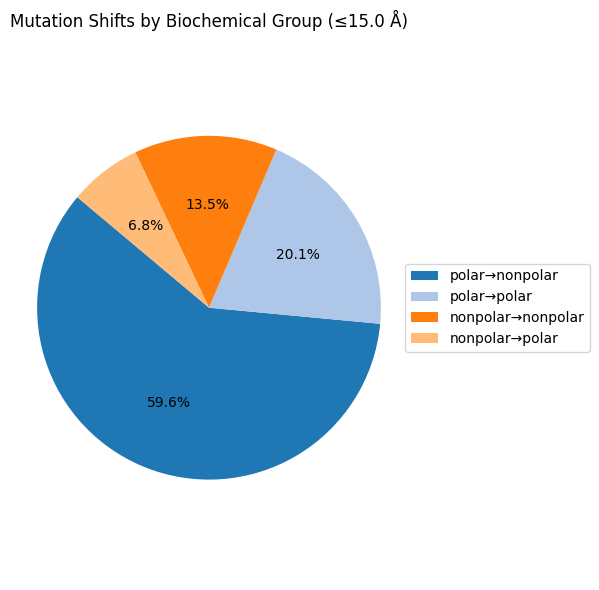

In [42]:
# Count shifts
shift_counts = df_near['shift_type'].value_counts()
colors = plt.cm.tab20.colors  # use a visually distinct palette

# Pie chart with legend
plt.figure(figsize=(6, 6))
patches, texts, _ = plt.pie(
    shift_counts,
    labels=None,
    colors=colors[:len(shift_counts)],
    autopct='%1.1f%%',
    startangle=140
)
plt.legend(patches, shift_counts.index, loc="center left", bbox_to_anchor=(1, 0.5))
plt.title(f"Mutation Shifts by Biochemical Group (≤{THRESHOLD} Å)")
plt.axis('equal')
plt.tight_layout()
plt.show()


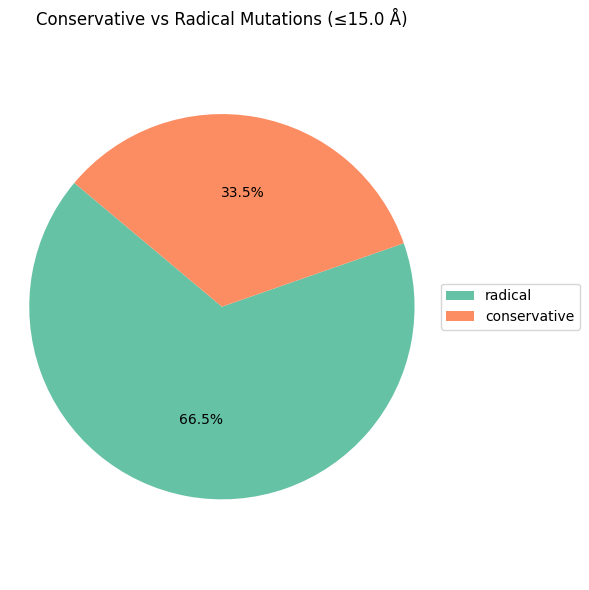

In [43]:
# Count conservative vs radical mutations
class_counts = df_near['change_class'].value_counts()
colors = ['#66c2a5', '#fc8d62']  # conservative / radical

# Pie chart with legend
plt.figure(figsize=(6, 6))
patches, texts, _ = plt.pie(
    class_counts,
    labels=None,
    colors=colors[:len(class_counts)],
    autopct='%1.1f%%',
    startangle=140
)
plt.legend(patches, class_counts.index, loc="center left", bbox_to_anchor=(1, 0.5))
plt.title(f"Conservative vs Radical Mutations (≤{THRESHOLD} Å)")
plt.axis('equal')
plt.tight_layout()
plt.show()



### Exercise 2: Which Ligands Are Most Affected by Nearby Mutations?

In this exercise, you will identify which ligands have the highest number of nearby mutations — those within **15 Å of the ligand-binding site centroid**.

Run the code to generate a bar chart showing the **number of mutations** near each ligand observed in KEAP1 structures.

---

### Questions:

1. Which ligand has the **highest number of nearby mutations**?

2. Do any ligands have significantly **more** or **fewer** mutations than others? 
 - What factors might explain this difference?

3. Choose one ligand from the plot and examine it more closely in the 3D viewer: 
 - Are the nearby mutations **clustered** in space or **spread out**?

---

> Hint: A ligand with many nearby mutations might indicate a region of biological importance or vulnerability.



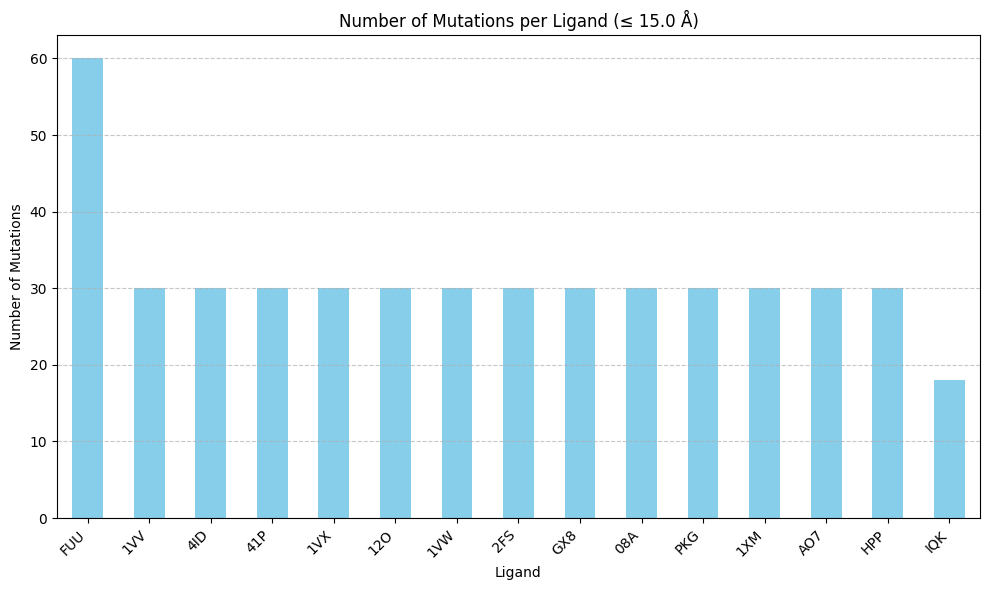

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('mutation_distances_clustered.csv')

# threshold Angstroms
threshold = 15.0  

# Filter mutations within threshold
within_threshold = df[df['DTM'] <= threshold]

# Count number of mutations per ligand
ligand_counts = within_threshold['ligand'].value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
ligand_counts.plot(kind='bar', color='skyblue')
plt.title(f"Number of Mutations per Ligand (≤ {threshold} Å)")
plt.xlabel("Ligand")
plt.ylabel("Number of Mutations")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Exercise 3: How Are Mutations Distributed Around Ligand-Binding Sites?

In this exercise, you will analyze the **spatial distribution** of mutations around ligand-binding sites using a radial histogram.

The plot groups mutations into distance ranges (bins), showing how many mutations fall within:
- 0–2 Å
- 2–4 Å
- ...
- up to 30 Å from the ligand centroid

---

### Questions:

1. **Which distance range contains the most mutations?** 
 - Are most mutations very close to the binding site, or more spread out?

2. Do you notice a **peak or drop-off** at a particular distance range?
 - What might explain this pattern?

3. Based on this distribution, where would you set a **reasonable cutoff** for "close" vs "far" mutations? 
 - Is 15 Å a good threshold?

4. **Why might the number of mutations drop** beyond a certain distance?

5. Choose one bin range (e.g., 6–8 Å). Use the dataset or viewer to examine:
 - What kind of mutations fall in this range?
 - Are they clustered around a specific ligand or structural feature?

---

> Hint: Regions near the ligand may be under stronger selective pressure or more sensitive to disruption.


/tmp/ipykernel_207/1861370021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['distance_bin'] = pd.cut(df_filtered['DTM'], bins=bins, labels=labels, include_lowest=True)
/tmp/ipykernel_207/1861370021.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bin_counts, x='Distance Range (Å)', y='Mutation Count', palette='viridis')


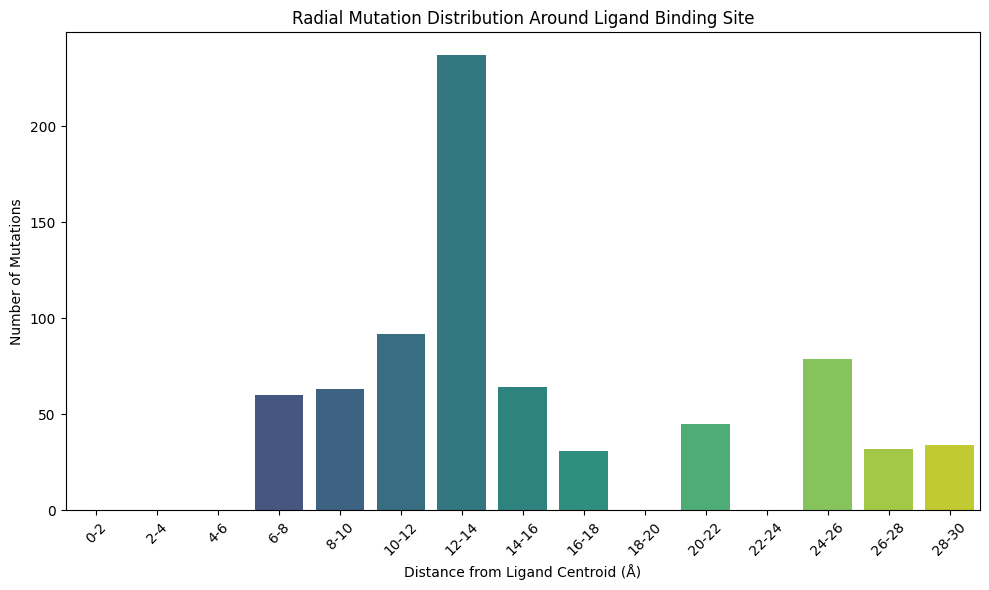

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the mutation dataset
df = pd.read_csv("mutation_distances_clustered.csv")

# Threshold to include mutations within a max distance from the centroid
MAX_DISTANCE = 30.0  # Ångstroms
BIN_WIDTH = 2.0      # Ångstroms

# Filter dataset
df_filtered = df[df['DTM'] <= MAX_DISTANCE]

# Create bins and labels
bins = np.arange(0, MAX_DISTANCE + BIN_WIDTH, BIN_WIDTH)
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
df_filtered['distance_bin'] = pd.cut(df_filtered['DTM'], bins=bins, labels=labels, include_lowest=True)

# Count mutations per distance bin
bin_counts = df_filtered['distance_bin'].value_counts().sort_index().reset_index()
bin_counts.columns = ['Distance Range (Å)', 'Mutation Count']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=bin_counts, x='Distance Range (Å)', y='Mutation Count', palette='viridis')
plt.xticks(rotation=45)
plt.title('Radial Mutation Distribution Around Ligand Binding Site')
plt.ylabel('Number of Mutations')
plt.xlabel('Distance from Ligand Centroid (Å)')
plt.tight_layout()


### Exercise 4: What Is the True Spatial Density of Mutations?

In Exercise 3, you looked at the **raw number of mutations** as a function of distance from the ligand-binding site.

But there is a catch:
- The **outer spherical shells** are much larger in volume than the inner ones.
- So even if more mutations appear in outer bins, it might just be because there is **more space** — not because mutations are actually more likely there.

---

### This analysis corrects for that by calculating:

#### **Mutation Density** = Number of Mutations / Volume of Radial Shell (in Å³)

This tells you the **true likelihood** of finding a mutation at different distances, normalized for how much space there is.

---

### After plotting the radial density histogram:

### Questions:

1. How does the **shape** of this plot compare to the one in Exercise 3?
 - Do the most populated bins still have the highest *density*?

2. In which radial shell is mutation density the **highest**?
 - What does this suggest about mutation clustering near the ligand?

3. Does mutation density decrease smoothly as you move outward, or are there **jumps and dips**?

4. Based on this new plot, do you want to **rethink the threshold** you used for classifying "near" vs "far"?

5. Which visualization gives a more accurate **biological interpretation**: raw counts or density?

---

> Hint: Always consider space when interpreting spatial data — more volume can mean more mutations, but not necessarily more concentration.

/tmp/ipykernel_207/2478770089.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['distance_bin'] = pd.cut(df_filtered['DTM'], bins=bins, labels=labels, include_lowest=True)


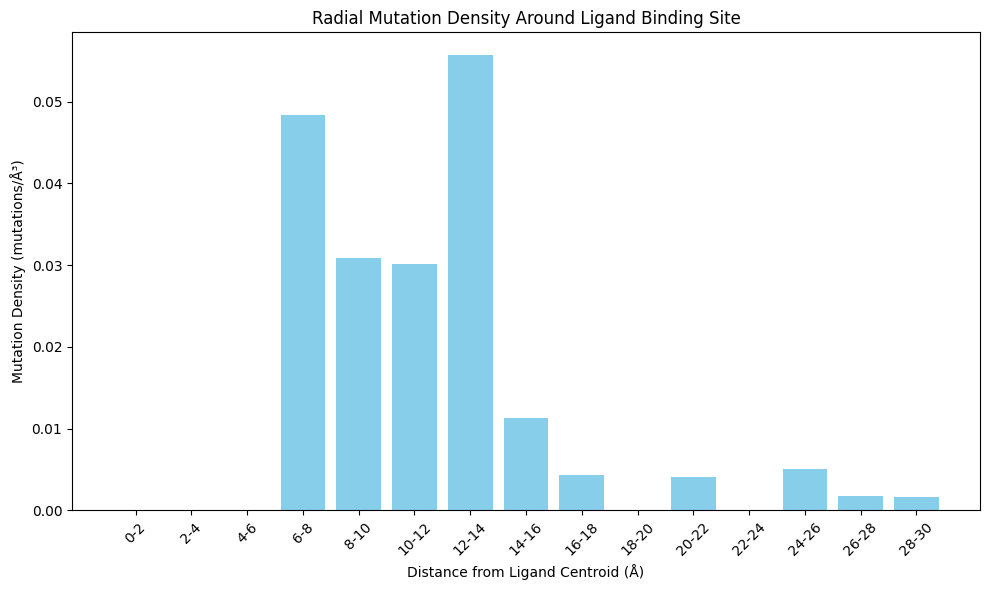

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the mutation dataset
df = pd.read_csv("mutation_distances_clustered.csv")

# Parameters
MAX_DISTANCE = 30.0  # Ångstroms
BIN_WIDTH = 2.0      # Ångstroms

# Filter dataset 
df_filtered = df[df['DTM'] <= MAX_DISTANCE]

# Define bin edges and labels
bins = np.arange(0, MAX_DISTANCE + BIN_WIDTH, BIN_WIDTH)
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins) - 1)]
df_filtered['distance_bin'] = pd.cut(df_filtered['DTM'], bins=bins, labels=labels, include_lowest=True)

# Count mutations per distance bin
bin_counts = df_filtered['distance_bin'].value_counts().sort_index().reset_index()
bin_counts.columns = ['Distance Range (Å)', 'Mutation Count']

# Compute volume of each spherical shell
r_outer = bins[1:]
r_inner = bins[:-1]
shell_volumes = (4/3) * np.pi * (r_outer**3 - r_inner**3)

# Add volumes and compute density
bin_counts['Shell Volume (Å³)'] = shell_volumes
bin_counts['Mutation Density'] = bin_counts['Mutation Count'] / bin_counts['Shell Volume (Å³)']

# Plot density histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_counts['Distance Range (Å)'], bin_counts['Mutation Density'], color='skyblue')
plt.xticks(rotation=45)
plt.title('Radial Mutation Density Around Ligand Binding Site')
plt.ylabel('Mutation Density (mutations/Å³)')
plt.xlabel('Distance from Ligand Centroid (Å)')
plt.tight_layout()
plt.show()

## Exercise 5: Using KDE to Analyze Mutation Distribution

In this exercise, you will explore mutation distances using a **Kernel Density Estimate (KDE)**.

---

### What is KDE?

A **KDE (Kernel Density Estimate)** is a way to estimate the probability distribution of a dataset by smoothing it into a continuous curve. 
Unlike histograms, which:
- Depend on arbitrary bin widths
- Can miss subtle trends

KDE:
- Shows smooth trends in data density
- Highlights local peaks and valleys
- Reveals where values concentrate most frequently

In this case, we are applying KDE to:
- Mutation distances (in Å)
- Filtered to mutations **within 15 Å of a ligand-binding site centroid**

---

### Why use KDE here?

You have already seen:
- **Histogram of mutation counts** (Exercise 3)
- **Density per volume** (Exercise 4)

But those were **bin-dependent**. KDE provides a **bin-free**, more flexible way to visualize:
- Are there **sharp peaks** of mutation accumulation?
- Are there **long tails** indicating a gradual drop-off?
- Does the distribution suggest **multiple mutation "hot zones"**?

---

### After plotting the KDE curve:

### Questions:

1. Does the KDE curve show a **single peak**, or multiple peaks?
 - What does that suggest about the spatial distribution of mutations?

2. Where is the **highest peak** located?
 - How far is that from the ligand-binding site?

3. Are there **regions where mutation density flattens out**?

4. How does this curve compare to:
 - The raw histogram (Exercise 3)?
 - The volume-corrected density plot (Exercise 4)?

5. Does the threshold line (15 Å) cut through a **high-density** or **low-density** region? 
 - Based on that, do you think 15 Å is a good cutoff for proximity?

---

> KDE is especially useful when you are looking for **patterns that are not tied to bin edges** — it reveals more nuanced spatial behavior.


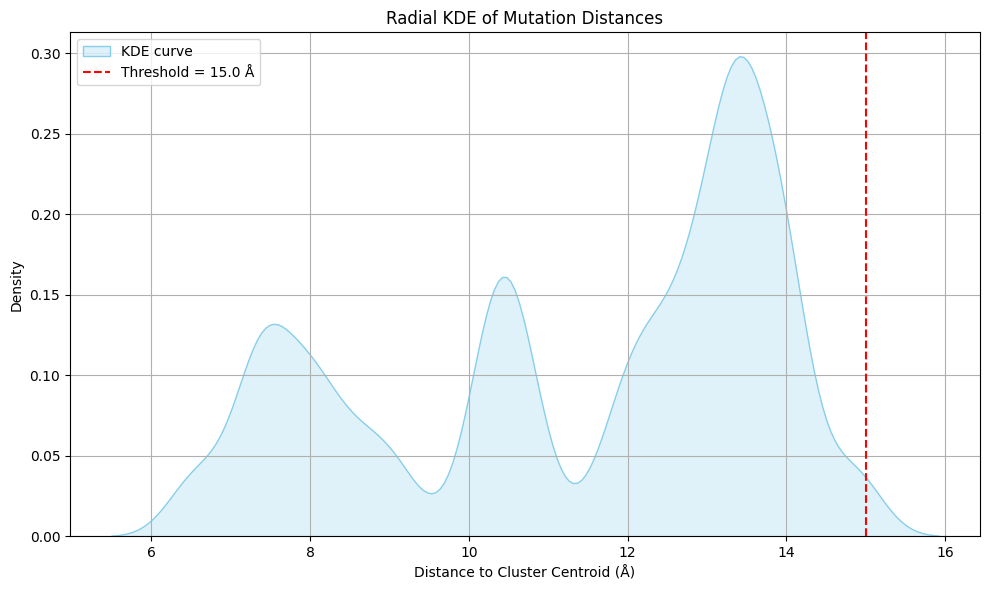

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Threshold in Angstroms
THRESHOLD = 15.0

# Load data
df = pd.read_csv("mutation_distances_clustered.csv")

# Filter to include only mutations within the threshold
filtered = df[df["DTM"] <= THRESHOLD]["DTM"].dropna()

# Create the KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(filtered, bw_adjust=0.5, fill=True, color="skyblue", label="KDE curve")
plt.axvline(THRESHOLD, color="red", linestyle="--", label=f"Threshold = {THRESHOLD} Å")
plt.xlabel("Distance to Cluster Centroid (Å)")
plt.ylabel("Density")
plt.title("Radial KDE of Mutation Distances")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


This workflow was developed by Jonnathan Castro at the University of North Carolina at Chapel Hill.